# Pre-processing et Feature Engineering - Étape 2

## Objectif
Transformer les données brutes en un dataset prêt pour la modélisation en :
- Nettoyant le HTML des descriptions
- Gérant les valeurs manquantes (35% de descriptions vides)
- Normalisant les textes
- Créant des features supplémentaires
- Préparant le dataset final pour la modélisation

## Plan
1. Chargement des données
2. Phase 1 : Nettoyage HTML
3. Phase 2 : Gestion des valeurs manquantes
4. Phase 3 : Normalisation des textes
5. Phase 4 : Feature Engineering
6. Phase 5 : Préparation finale et sauvegarde
7. Statistiques et validation



In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Ajouter le dossier src au path pour importer les modules
sys.path.append(str(Path('../').resolve()))

# Import des modules de preprocessing
from src.utils.data_loader import load_data, save_data
from src.preprocessing import (
    clean_html,
    decode_html_entities,
    has_html,
    normalize_text,
    combine_texts,
    create_length_features,
    create_binary_features,
    create_quality_features,
    PreprocessingPipeline
)

# Configuration des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Bibliothèques importées avec succès")



✅ Bibliothèques importées avec succès


## 1. Chargement des Données

Chargement des données brutes depuis le dossier `data brut/`.


In [2]:
# Chargement des données
DATA_DIR = Path('../data brut')

X_train, y_train, X_test = load_data(data_dir=DATA_DIR)

# Vérification de l'alignement
if X_train.shape[0] == y_train.shape[0]:
    print(f"\n✅ Alignement OK : X_train et y_train ont le même nombre de lignes")
else:
    print(f"\n⚠️  ATTENTION : X_train et y_train n'ont pas le même nombre de lignes !")

# Aperçu des données
print("\n" + "="*80)
print("APERÇU DE X_train (avant preprocessing)")
print("="*80)
print(X_train.head())
print(f"\nValeurs manquantes :")
print(X_train.isnull().sum())



🔄 Chargement des données...
✅ Données chargées avec succès !
  - X_train : 84,916 lignes × 5 colonnes
  - y_train : 84,916 lignes × 2 colonnes
  - X_test  : 13,812 lignes × 5 colonnes

✅ Alignement OK : X_train et y_train ont le même nombre de lignes

APERÇU DE X_train (avant preprocessing)
   Unnamed: 0                                        designation  \
0           0  Olivia: Personalisiertes Notizbuch / 150 Seite...   
1           1  Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...   
2           2  Grand Stylet Ergonomique Bleu Gamepad Nintendo...   
3           3  Peluche Donald - Europe - Disneyland 2000 (Mar...   
4           4                               La Guerre Des Tuques   

                                         description   productid     imageid  
0                                                NaN  3804725264  1263597046  
1                                                NaN   436067568  1008141237  
2  PILOT STYLE Touch Pen de marque Speedlink est ...   2011151

## 2. Phase 1 : Nettoyage HTML

### 2.1 Analyse du HTML avant nettoyage


In [3]:
# Détection du HTML dans les descriptions
X_train['has_html_before'] = X_train['description'].apply(has_html)
X_test['has_html_before'] = X_test['description'].apply(has_html)

html_count_train = X_train['has_html_before'].sum()
html_count_test = X_test['has_html_before'].sum()

print("📊 Présence de HTML dans les descriptions (AVANT nettoyage) :")
print(f"  - X_train : {html_count_train} descriptions avec HTML ({html_count_train/len(X_train)*100:.2f}%)")
print(f"  - X_test : {html_count_test} descriptions avec HTML ({html_count_test/len(X_test)*100:.2f}%)")

# Exemples de descriptions avec HTML
print("\n📝 Exemples de descriptions avec HTML :")
html_examples = X_train[X_train['has_html_before']]['description'].head(3)
for idx, desc in enumerate(html_examples, 1):
    print(f"\nExemple {idx} (premiers 200 caractères) :")
    print(desc[:200] + "...")



📊 Présence de HTML dans les descriptions (AVANT nettoyage) :
  - X_train : 15645 descriptions avec HTML (18.42%)
  - X_test : 2478 descriptions avec HTML (17.94%)

📝 Exemples de descriptions avec HTML :

Exemple 1 (premiers 200 caractères) :
PILOT STYLE Touch Pen de marque Speedlink est 1 stylet ergonomique pour GamePad Nintendo Wii U.<br> Pour un confort optimal et une précision maximale sur le GamePad de la Wii U: ce grand stylet hautem...

Exemple 2 (premiers 200 caractères) :
Tente pliante V3S5 Pro PVC 500 gr/m² - 3 x 4m50.Que vous soyez un particulier pour votre jardin ou un professionnel pour stand commercial ou pour vos réceptions le barnum V3S5 Pro de 135 m² sera vous ...

Exemple 3 (premiers 200 caractères) :
The timeless DSW seat can now be paired with more types of legs! These wood legs look like a natural fit for the seat and will make a safe choice for any interior. This chair will be perfect  in offic...


### 2.2 Nettoyage du HTML


In [4]:
# Nettoyage HTML des descriptions
print("🔄 Nettoyage du HTML...")

X_train['description_clean'] = X_train['description'].apply(
    lambda x: clean_html(x, preserve_structure=True)
)
X_test['description_clean'] = X_test['description'].apply(
    lambda x: clean_html(x, preserve_structure=True)
)

# Vérification après nettoyage
X_train['has_html_after'] = X_train['description_clean'].apply(has_html)
X_test['has_html_after'] = X_test['description_clean'].apply(has_html)

html_remaining_train = X_train['has_html_after'].sum()
html_remaining_test = X_test['has_html_after'].sum()

print(f"✅ Nettoyage terminé !")
print(f"  - X_train : {html_remaining_train} descriptions avec HTML restant ({html_remaining_train/len(X_train)*100:.2f}%)")
print(f"  - X_test : {html_remaining_test} descriptions avec HTML restant ({html_remaining_test/len(X_test)*100:.2f}%)")

# Comparaison longueurs avant/après
X_train['desc_length_before'] = X_train['description'].fillna('').astype(str).str.len()
X_train['desc_length_after'] = X_train['description_clean'].str.len()

print(f"\n📊 Comparaison des longueurs (X_train) :")
print(f"  - Avant nettoyage : moyenne = {X_train['desc_length_before'].mean():.1f}, médiane = {X_train['desc_length_before'].median():.1f}")
print(f"  - Après nettoyage : moyenne = {X_train['desc_length_after'].mean():.1f}, médiane = {X_train['desc_length_after'].median():.1f}")

# Exemples après nettoyage
print("\n📝 Exemples de descriptions nettoyées :")
for idx, (before, after) in enumerate(zip(
    X_train[X_train['has_html_before']]['description'].head(3),
    X_train[X_train['has_html_before']]['description_clean'].head(3)
), 1):
    print(f"\nExemple {idx} :")
    print(f"  AVANT (premiers 150 caractères) : {before[:150]}...")
    print(f"  APRÈS (premiers 150 caractères) : {after[:150]}...")



🔄 Nettoyage du HTML...
✅ Nettoyage terminé !
  - X_train : 103 descriptions avec HTML restant (0.12%)
  - X_test : 14 descriptions avec HTML restant (0.10%)

📊 Comparaison des longueurs (X_train) :
  - Avant nettoyage : moyenne = 524.6, médiane = 231.0
  - Après nettoyage : moyenne = 488.9, médiane = 220.0

📝 Exemples de descriptions nettoyées :

Exemple 1 :
  AVANT (premiers 150 caractères) : PILOT STYLE Touch Pen de marque Speedlink est 1 stylet ergonomique pour GamePad Nintendo Wii U.<br> Pour un confort optimal et une précision maximale ...
  APRÈS (premiers 150 caractères) : PILOT STYLE Touch Pen de marque Speedlink est 1 stylet ergonomique pour GamePad Nintendo Wii U. Pour un confort optimal et une précision maximale sur ...

Exemple 2 :
  AVANT (premiers 150 caractères) : Tente pliante V3S5 Pro PVC 500 gr/m² - 3 x 4m50.Que vous soyez un particulier pour votre jardin ou un professionnel pour stand commercial ou pour vos ...
  APRÈS (premiers 150 caractères) : Tente pliante V3S5 P

## 3. Phase 2 : Gestion des Valeurs Manquantes

### 3.1 Analyse des valeurs manquantes


In [5]:
# Analyse des valeurs manquantes
missing_train = X_train['description_clean'].isna() | (X_train['description_clean'] == '')
missing_test = X_test['description_clean'].isna() | (X_test['description_clean'] == '')

missing_count_train = missing_train.sum()
missing_count_test = missing_test.sum()

print("📊 Analyse des valeurs manquantes (descriptions) :")
print(f"  - X_train : {missing_count_train} descriptions vides ({missing_count_train/len(X_train)*100:.2f}%)")
print(f"  - X_test : {missing_count_test} descriptions vides ({missing_count_test/len(X_test)*100:.2f}%)")

# Analyse par classe (si y_train disponible)
if 'prdtypecode' not in X_train.columns:
    # Fusionner avec y_train pour analyser par classe
    df_train_merged = pd.concat([X_train, y_train], axis=1)
else:
    df_train_merged = X_train.copy()

if 'prdtypecode' in df_train_merged.columns:
    missing_by_class = df_train_merged.groupby('prdtypecode').agg({
        'description_clean': lambda x: (x.isna() | (x == '')).sum() / len(x) * 100
    }).round(2).sort_values('description_clean', ascending=False)
    
    print(f"\n📊 Top 10 classes avec le plus de descriptions manquantes :")
    print(missing_by_class.head(10))



📊 Analyse des valeurs manquantes (descriptions) :
  - X_train : 29888 descriptions vides (35.20%)
  - X_test : 4903 descriptions vides (35.50%)

📊 Top 10 classes avec le plus de descriptions manquantes :
             description_clean
prdtypecode                   
2403                     97.36
2462                     96.27
2280                     93.28
1160                     91.17
10                       89.15
1180                     79.97
40                       65.47
1140                     64.62
2705                     37.12
1320                     33.97


### 3.2 Application de la stratégie de gestion des valeurs manquantes

**Stratégie choisie :** `designation_only` - Pour les produits sans description, on utilisera uniquement la designation.


In [6]:
# Les descriptions vides sont déjà gérées (chaîne vide)
# On s'assure qu'elles sont bien des chaînes vides et non NaN
X_train['description_clean'] = X_train['description_clean'].fillna('')
X_test['description_clean'] = X_test['description_clean'].fillna('')

print("✅ Valeurs manquantes gérées : descriptions vides remplacées par chaîne vide")
print(f"  - X_train : {X_train['description_clean'].isna().sum()} NaN restants")
print(f"  - X_test : {X_test['description_clean'].isna().sum()} NaN restants")



✅ Valeurs manquantes gérées : descriptions vides remplacées par chaîne vide
  - X_train : 0 NaN restants
  - X_test : 0 NaN restants


## 4. Phase 3 : Normalisation des Textes

Normalisation des désignations et descriptions nettoyées.


In [7]:
# Normalisation des textes
print("🔄 Normalisation des textes...")

# Normalisation des désignations
X_train['designation_clean'] = X_train['designation'].apply(
    lambda x: normalize_text(x, lowercase=True, remove_extra_spaces=True, remove_accents=False)
)
X_test['designation_clean'] = X_test['designation'].apply(
    lambda x: normalize_text(x, lowercase=True, remove_extra_spaces=True, remove_accents=False)
)

# Normalisation des descriptions (déjà nettoyées du HTML)
X_train['description_clean'] = X_train['description_clean'].apply(
    lambda x: normalize_text(x, lowercase=True, remove_extra_spaces=True, remove_accents=False)
)
X_test['description_clean'] = X_test['description_clean'].apply(
    lambda x: normalize_text(x, lowercase=True, remove_extra_spaces=True, remove_accents=False)
)

print("✅ Normalisation terminée !")

# Exemples
print("\n📝 Exemples de textes normalisés :")
for idx in range(3):
    print(f"\nExemple {idx+1} :")
    print(f"  Designation originale : {X_train['designation'].iloc[idx][:100]}...")
    print(f"  Designation normalisée : {X_train['designation_clean'].iloc[idx][:100]}...")



🔄 Normalisation des textes...
✅ Normalisation terminée !

📝 Exemples de textes normalisés :

Exemple 1 :
  Designation originale : Olivia: Personalisiertes Notizbuch / 150 Seiten / Punktraster / Ca Din A5 / Rosen-Design...
  Designation normalisée : olivia: personalisiertes notizbuch / 150 seiten / punktraster / ca din a5 / rosen-design...

Exemple 2 :
  Designation originale : Journal Des Arts (Le) N° 133 Du 28/09/2001 - L'art Et Son Marche Salon D'art Asiatique A Paris - Jac...
  Designation normalisée : journal des arts (le) n° 133 du 28/09/2001 - l'art et son marche salon d'art asiatique a paris - jac...

Exemple 3 :
  Designation originale : Grand Stylet Ergonomique Bleu Gamepad Nintendo Wii U - Speedlink Pilot Style...
  Designation normalisée : grand stylet ergonomique bleu gamepad nintendo wii u - speedlink pilot style...


## 5. Phase 4 : Feature Engineering

Création de features supplémentaires pour améliorer la classification.


In [8]:
# Création de toutes les features
print("🔄 Création des features...")

# Utiliser les colonnes originales pour les features de longueur
X_train_features = X_train[['designation', 'description']].copy()
X_test_features = X_test[['designation', 'description']].copy()

# Créer les features
X_train_features = create_length_features(X_train_features)
X_train_features = create_binary_features(X_train_features)
X_train_features = create_quality_features(X_train_features)

X_test_features = create_length_features(X_test_features)
X_test_features = create_binary_features(X_test_features)
X_test_features = create_quality_features(X_test_features)

# Ajouter les features au DataFrame principal
feature_cols = [col for col in X_train_features.columns if col not in ['designation', 'description']]
for col in feature_cols:
    X_train[col] = X_train_features[col]
    X_test[col] = X_test_features[col]

print(f"✅ {len(feature_cols)} features créées :")
for col in feature_cols:
    print(f"  - {col}")

# Aperçu des features
print("\n📊 Aperçu des features créées :")
print(X_train[feature_cols].describe())



🔄 Création des features...
✅ 14 features créées :
  - designation_length
  - description_length
  - total_text_length
  - designation_word_count
  - description_word_count
  - total_word_count
  - designation_avg_word_length
  - description_avg_word_length
  - has_description
  - has_html
  - is_description_empty
  - text_completeness
  - description_quality_score
  - word_density

📊 Aperçu des features créées :
       designation_length  description_length  total_text_length  \
count        84916.000000        84916.000000       84916.000000   
mean            70.163303          524.555926         594.719228   
std             36.793383          754.893905         762.067621   
min             11.000000            0.000000          11.000000   
25%             43.000000            0.000000          65.000000   
50%             64.000000          231.000000         313.000000   
75%             90.000000          823.000000         903.000000   
max            250.000000        12451.0

## 6. Phase 5 : Préparation Finale

### 6.1 Combinaison des textes


In [9]:
# Combiner designation et description en un seul texte
print("🔄 Combinaison des textes...")

X_train['text_combined'] = X_train.apply(
    lambda row: combine_texts(
        row['designation_clean'],
        row['description_clean'],
        separator=' ',
        handle_missing='designation_only'
    ),
    axis=1
)

X_test['text_combined'] = X_test.apply(
    lambda row: combine_texts(
        row['designation_clean'],
        row['description_clean'],
        separator=' ',
        handle_missing='designation_only'
    ),
    axis=1
)

print("✅ Textes combinés !")

# Statistiques sur les textes combinés
print(f"\n📊 Statistiques sur les textes combinés (X_train) :")
print(f"  - Longueur moyenne : {X_train['text_combined'].str.len().mean():.1f} caractères")
print(f"  - Longueur médiane : {X_train['text_combined'].str.len().median():.1f} caractères")
print(f"  - Longueur min : {X_train['text_combined'].str.len().min()} caractères")
print(f"  - Longueur max : {X_train['text_combined'].str.len().max()} caractères")

# Vérifier qu'il n'y a pas de textes vides
empty_texts = (X_train['text_combined'] == '').sum()
print(f"  - Textes vides : {empty_texts} ({empty_texts/len(X_train)*100:.2f}%)")



🔄 Combinaison des textes...
✅ Textes combinés !

📊 Statistiques sur les textes combinés (X_train) :
  - Longueur moyenne : 559.2 caractères
  - Longueur médiane : 292.0 caractères
  - Longueur min : 11 caractères
  - Longueur max : 12212 caractères
  - Textes vides : 0 (0.00%)


### 6.2 Préparation des datasets finaux


In [10]:
# Sélectionner les colonnes importantes pour le dataset final
columns_to_keep = [
    'productid',
    'imageid',
    'designation_clean',
    'description_clean',
    'text_combined',
    'designation_length',
    'description_length',
    'total_text_length',
    'designation_word_count',
    'description_word_count',
    'total_word_count',
    'has_description',
    'has_html',
    'is_description_empty',
    'text_completeness',
    'description_quality_score',
    'word_density'
]

# Créer les datasets finaux
X_train_final = X_train[columns_to_keep].copy()
X_test_final = X_test[columns_to_keep].copy()

print("✅ Datasets finaux préparés !")
print(f"\n📊 Structure des datasets finaux :")
print(f"  - X_train_final : {X_train_final.shape[0]:,} lignes × {X_train_final.shape[1]} colonnes")
print(f"  - X_test_final : {X_test_final.shape[0]:,} lignes × {X_test_final.shape[1]} colonnes")
print(f"\nColonnes :")
for col in columns_to_keep:
    print(f"  - {col}")



✅ Datasets finaux préparés !

📊 Structure des datasets finaux :
  - X_train_final : 84,916 lignes × 17 colonnes
  - X_test_final : 13,812 lignes × 17 colonnes

Colonnes :
  - productid
  - imageid
  - designation_clean
  - description_clean
  - text_combined
  - designation_length
  - description_length
  - total_text_length
  - designation_word_count
  - description_word_count
  - total_word_count
  - has_description
  - has_html
  - is_description_empty
  - text_completeness
  - description_quality_score
  - word_density


### 6.3 Sauvegarde des datasets nettoyés


In [11]:
# Sauvegarder les datasets nettoyés
OUTPUT_DIR = Path('../data/processed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("💾 Sauvegarde des datasets...")

# Sauvegarder les datasets finaux
save_data(X_train_final, OUTPUT_DIR / 'X_train_clean.csv')
save_data(X_test_final, OUTPUT_DIR / 'X_test_clean.csv')
save_data(y_train, OUTPUT_DIR / 'y_train.csv')

print("\n✅ Datasets sauvegardés dans :", OUTPUT_DIR)



💾 Sauvegarde des datasets...
✅ Données sauvegardées : ..\data\processed\X_train_clean.csv
✅ Données sauvegardées : ..\data\processed\X_test_clean.csv
✅ Données sauvegardées : ..\data\processed\y_train.csv

✅ Datasets sauvegardés dans : ..\data\processed


## 7. Statistiques et Validation

### 7.1 Comparaison avant/après preprocessing


In [12]:
# Recharger les données originales pour comparaison
X_train_original, _, _ = load_data(data_dir=DATA_DIR)

print("="*80)
print("COMPARAISON AVANT / APRÈS PREPROCESSING")
print("="*80)

# Statistiques avant
print("\n📊 AVANT PREPROCESSING :")
print(f"  - Descriptions avec HTML : {X_train_original['description'].apply(has_html).sum()} ({X_train_original['description'].apply(has_html).sum()/len(X_train_original)*100:.2f}%)")
print(f"  - Descriptions manquantes : {X_train_original['description'].isna().sum()} ({X_train_original['description'].isna().sum()/len(X_train_original)*100:.2f}%)")
print(f"  - Longueur moyenne description : {X_train_original['description'].fillna('').astype(str).str.len().mean():.1f} caractères")

# Statistiques après
# Vérifier le HTML sur les descriptions nettoyées (pas sur has_html qui est calculé avant nettoyage)
html_after_clean = X_train_final['description_clean'].apply(has_html).sum()
print("\n📊 APRÈS PREPROCESSING :")
print(f"  - Descriptions avec HTML restant : {html_after_clean} ({html_after_clean/len(X_train_final)*100:.2f}%)")
print(f"  - Descriptions vides : {(X_train_final['description_clean'] == '').sum()} ({(X_train_final['description_clean'] == '').sum()/len(X_train_final)*100:.2f}%)")
print(f"  - Longueur moyenne text_combined : {X_train_final['text_combined'].str.len().mean():.1f} caractères")
print(f"  - Features créées : {len([c for c in X_train_final.columns if c not in ['productid', 'imageid', 'designation_clean', 'description_clean', 'text_combined']])}")



🔄 Chargement des données...
✅ Données chargées avec succès !
  - X_train : 84,916 lignes × 5 colonnes
  - y_train : 84,916 lignes × 2 colonnes
  - X_test  : 13,812 lignes × 5 colonnes
COMPARAISON AVANT / APRÈS PREPROCESSING

📊 AVANT PREPROCESSING :
  - Descriptions avec HTML : 15645 (18.42%)
  - Descriptions manquantes : 29800 (35.09%)
  - Longueur moyenne description : 524.6 caractères

📊 APRÈS PREPROCESSING :
  - Descriptions avec HTML restant : 103 (0.12%)
  - Descriptions vides : 29888 (35.20%)
  - Longueur moyenne text_combined : 559.2 caractères
  - Features créées : 12


### 7.2 Visualisations de validation


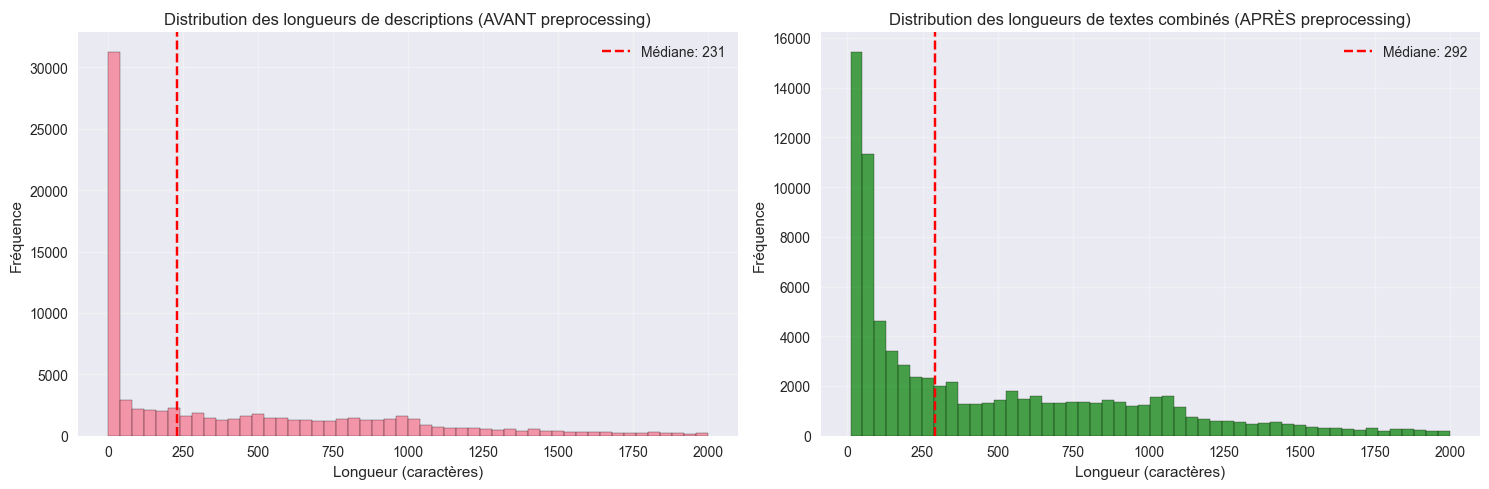

In [13]:
# Visualisation 1 : Distribution des longueurs avant/après
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Avant
desc_lengths_before = X_train_original['description'].fillna('').astype(str).str.len()
axes[0].hist(desc_lengths_before[desc_lengths_before < 2000], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Longueur (caractères)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des longueurs de descriptions (AVANT preprocessing)')
axes[0].axvline(desc_lengths_before.median(), color='r', linestyle='--', label=f'Médiane: {desc_lengths_before.median():.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Après
desc_lengths_after = X_train_final['text_combined'].str.len()
axes[1].hist(desc_lengths_after[desc_lengths_after < 2000], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Longueur (caractères)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des longueurs de textes combinés (APRÈS preprocessing)')
axes[1].axvline(desc_lengths_after.median(), color='r', linestyle='--', label=f'Médiane: {desc_lengths_after.median():.0f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



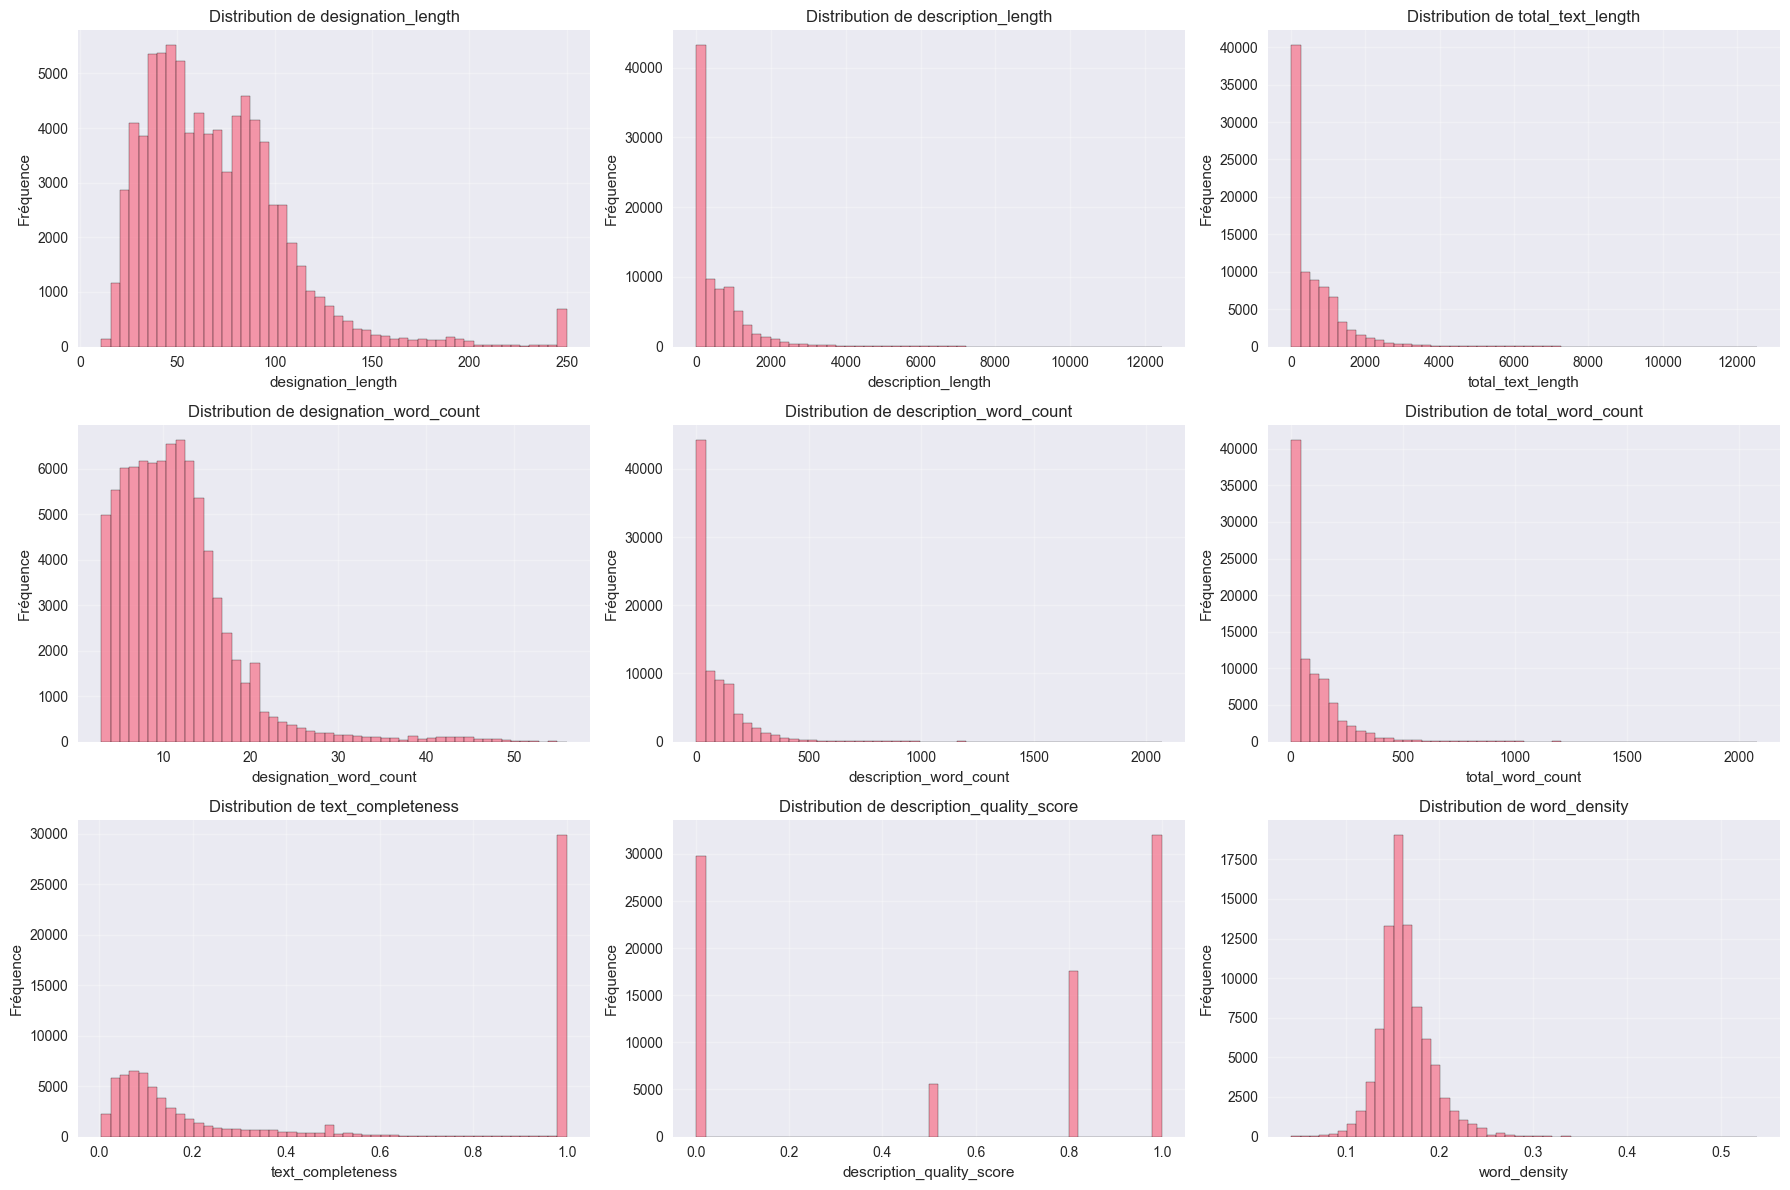

In [14]:
# Visualisation 2 : Features créées
feature_cols_numeric = [
    'designation_length', 'description_length', 'total_text_length',
    'designation_word_count', 'description_word_count', 'total_word_count',
    'text_completeness', 'description_quality_score', 'word_density'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(feature_cols_numeric):
    if col in X_train_final.columns:
        axes[idx].hist(X_train_final[col], bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Fréquence')
        axes[idx].set_title(f'Distribution de {col}')
        axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()



### 7.3 Validation finale

Vérification de la cohérence des données et absence d'erreurs.


In [15]:
# Validation finale
print("="*80)
print("VALIDATION FINALE")
print("="*80)

# Vérifications
checks = []

# 1. Pas de NaN dans les colonnes importantes
checks.append(('Pas de NaN dans text_combined', X_train_final['text_combined'].isna().sum() == 0))
checks.append(('Pas de NaN dans designation_clean', X_train_final['designation_clean'].isna().sum() == 0))

# 2. Pas de textes vides
checks.append(('Pas de textes vides', (X_train_final['text_combined'] == '').sum() == 0))

# 3. Cohérence train/test
checks.append(('Même nombre de colonnes train/test', X_train_final.shape[1] == X_test_final.shape[1]))
checks.append(('Colonnes identiques train/test', list(X_train_final.columns) == list(X_test_final.columns)))

# 4. Pas de HTML restant (vérifier sur les descriptions nettoyées)
html_remaining_clean = X_train_final['description_clean'].apply(has_html).sum()
checks.append(('Pas de HTML restant dans description_clean', html_remaining_clean == 0))

# Afficher les résultats
print("\n✅ Résultats des vérifications :")
for check_name, check_result in checks:
    status = "✅" if check_result else "❌"
    print(f"  {status} {check_name}")

all_passed = all(result for _, result in checks)
if all_passed:
    print("\n🎉 Toutes les validations sont passées ! Le dataset est prêt pour la modélisation.")
else:
    print("\n⚠️  Certaines validations ont échoué. Vérifiez les données.")
    
# Si HTML restant, investiguer
if html_remaining_clean > 0:
    print(f"\n🔍 Investigation des {html_remaining_clean} descriptions avec HTML restant...")



VALIDATION FINALE

✅ Résultats des vérifications :
  ✅ Pas de NaN dans text_combined
  ✅ Pas de NaN dans designation_clean
  ✅ Pas de textes vides
  ✅ Même nombre de colonnes train/test
  ✅ Colonnes identiques train/test
  ❌ Pas de HTML restant dans description_clean

⚠️  Certaines validations ont échoué. Vérifiez les données.

🔍 Investigation des 103 descriptions avec HTML restant...


### 7.4 Investigation du HTML Restant

Analyse des descriptions qui contiennent encore du HTML après nettoyage.


In [16]:
# Identifier les descriptions avec HTML restant
html_remaining_mask = X_train_final['description_clean'].apply(has_html)
html_remaining_descriptions = X_train_final[html_remaining_mask].copy()

print(f"📊 Analyse des {len(html_remaining_descriptions)} descriptions avec HTML restant :\n")

# S'assurer que X_train est accessible (recharger si nécessaire)
if 'X_train' not in locals() or X_train is None:
    X_train, _, _ = load_data(data_dir=DATA_DIR)

# Afficher quelques exemples
print("="*80)
print("EXEMPLES DE DESCRIPTIONS AVEC HTML RESTANT")
print("="*80)

for idx, row in html_remaining_descriptions.head(10).iterrows():
    print(f"\n--- Exemple {idx} ---")
    print(f"ProductID: {row['productid']}")
    print(f"Description originale (premiers 300 caractères):")
    # Récupérer la description originale depuis X_train
    original_desc = X_train.loc[X_train['productid'] == row['productid'], 'description'].values
    if len(original_desc) > 0:
        print(f"  {str(original_desc[0])[:300]}...")
    print(f"\nDescription nettoyée (premiers 300 caractères):")
    print(f"  {row['description_clean'][:300]}...")
    print(f"\nHTML détecté dans description_clean: {has_html(row['description_clean'])}")
    
    # Extraire les tags HTML restants
    import re
    html_tags = re.findall(r'<[^>]+>', row['description_clean'])
    if html_tags:
        print(f"Tags HTML trouvés: {html_tags[:5]}")  # Limiter à 5 tags


📊 Analyse des 103 descriptions avec HTML restant :

EXEMPLES DE DESCRIPTIONS AVEC HTML RESTANT

--- Exemple 394 ---
ProductID: 4029127976
Description originale (premiers 300 caractères):
  <p>  <strong>Le musy</strong> <strong>un lange plus petit pour réconforter bébé...</strong><br />  <br />  Lot de 3 petits Langes en mousseline de coton PACIFIC PARADISE aden &#43; anais en mousseline de coton.</p> <p>  Découvrez le lange en mousseline de coton :<br />  Un lange en mousseline de cot...

Description nettoyée (premiers 300 caractères):
  le musy un lange plus petit pour réconforter bébé... lot de 3 petits langes en mousseline de coton pacific paradise aden + anais en mousseline de coton. découvrez le lange en mousseline de coton : un lange en mousseline de coton (100%) doublé mesurant 70 cm x 70 cm. inédit par sa légère élasticité e...

HTML détecté dans description_clean: True
Tags HTML trouvés: ['<< aden + anais >', '<< burpy bib >', '<< made for baby. designed for you >']

--- Exemp

In [17]:
# Analyser les patterns de HTML restant
import re
from collections import Counter

print("\n" + "="*80)
print("ANALYSE DES PATTERNS DE HTML RESTANT")
print("="*80)

# Extraire tous les tags HTML restants
all_remaining_tags = []
all_remaining_texts = []

for desc in html_remaining_descriptions['description_clean']:
    if has_html(desc):
        tags = re.findall(r'<[^>]+>', desc)
        all_remaining_tags.extend(tags)
        all_remaining_texts.append(desc)

# Compter les tags les plus fréquents
tag_counter = Counter(all_remaining_tags)
print(f"\n📊 Top 20 tags HTML les plus fréquents dans les descriptions restantes :")
for tag, count in tag_counter.most_common(20):
    print(f"  {tag}: {count} occurrences")

# Analyser les types de tags
print(f"\n📊 Types de tags HTML restants :")
tag_types = {}
for tag in all_remaining_tags:
    tag_name = re.match(r'</?(\w+)', tag)
    if tag_name:
        tag_type = tag_name.group(1)
        tag_types[tag_type] = tag_types.get(tag_type, 0) + 1

for tag_type, count in sorted(tag_types.items(), key=lambda x: x[1], reverse=True):
    print(f"  {tag_type}: {count} occurrences")



ANALYSE DES PATTERNS DE HTML RESTANT

📊 Top 20 tags HTML les plus fréquents dans les descriptions restantes :
  <br/>: 104 occurrences
  < li>: 83 occurrences
  <br />: 23 occurrences
  < br / >: 17 occurrences
  </ p>: 16 occurrences
  < ul>: 15 occurrences
  </ b>: 14 occurrences
  <p>: 9 occurrences
  </p>: 9 occurrences
  </ li>: 8 occurrences
  </li>: 8 occurrences
  <li>: 7 occurrences
  < strong>: 6 occurrences
  < div>: 6 occurrences
  < a>: 5 occurrences
  < br>: 5 occurrences
  < span>: 4 occurrences
  < b>: 3 occurrences
  </ span>: 3 occurrences
  < br />: 3 occurrences

📊 Types de tags HTML restants :
  br: 127 occurrences
  p: 18 occurrences
  li: 15 occurrences
  1l: 7 occurrences
  36db: 3 occurrences
  a: 2 occurrences
  span: 2 occurrences
  strong: 2 occurrences
  10: 1 occurrences


In [18]:
# Tester pourquoi BeautifulSoup n'a pas nettoyé ces cas
from bs4 import BeautifulSoup

print("\n" + "="*80)
print("TEST DE NETTOYAGE AVEC BEAUTIFULSOUP")
print("="*80)

# S'assurer que X_train est accessible
if 'X_train' not in locals() or X_train is None:
    X_train, _, _ = load_data(data_dir=DATA_DIR)

# Prendre quelques exemples et tester le nettoyage
test_examples = html_remaining_descriptions.head(5)

for idx, row in test_examples.iterrows():
    print(f"\n--- Test {idx} ---")
    original_desc = X_train.loc[X_train['productid'] == row['productid'], 'description'].values
    if len(original_desc) > 0:
        original_desc = str(original_desc[0])
    else:
        original_desc = "Non trouvé"
    cleaned_desc = row['description_clean']
    
    print(f"Description originale (premiers 200 caractères):")
    print(f"  {original_desc[:200]}...")
    
    print(f"\nDescription nettoyée actuelle (premiers 200 caractères):")
    print(f"  {cleaned_desc[:200]}...")
    
    # Tester un nettoyage manuel
    try:
        soup = BeautifulSoup(cleaned_desc, 'html.parser')
        manual_clean = soup.get_text(separator=' ', strip=True)
        print(f"\nNettoyage manuel avec BeautifulSoup (premiers 200 caractères):")
        print(f"  {manual_clean[:200]}...")
        
        # Vérifier si le nettoyage manuel a fonctionné
        if has_html(manual_clean):
            print(f"  ⚠️  HTML toujours présent après nettoyage manuel")
            # Extraire les tags restants
            remaining_tags = re.findall(r'<[^>]+>', manual_clean)
            print(f"  Tags restants: {remaining_tags[:5]}")
        else:
            print(f"  ✅ HTML supprimé avec succès")
    except Exception as e:
        print(f"  ❌ Erreur lors du nettoyage: {e}")



TEST DE NETTOYAGE AVEC BEAUTIFULSOUP

--- Test 394 ---
Description originale (premiers 200 caractères):
  <p>  <strong>Le musy</strong> <strong>un lange plus petit pour réconforter bébé...</strong><br />  <br />  Lot de 3 petits Langes en mousseline de coton PACIFIC PARADISE aden &#43; anais en mousseline...

Description nettoyée actuelle (premiers 200 caractères):
  le musy un lange plus petit pour réconforter bébé... lot de 3 petits langes en mousseline de coton pacific paradise aden + anais en mousseline de coton. découvrez le lange en mousseline de coton : un ...

Nettoyage manuel avec BeautifulSoup (premiers 200 caractères):
  le musy un lange plus petit pour réconforter bébé... lot de 3 petits langes en mousseline de coton pacific paradise aden + anais en mousseline de coton. découvrez le lange en mousseline de coton : un ...
  ⚠️  HTML toujours présent après nettoyage manuel
  Tags restants: ['<< aden + anais >', '<< burpy bib >', '<< made for baby. designed for you >']

--- Te

In [19]:
# Analyser les cas où le HTML est dans des attributs ou malformé
print("\n" + "="*80)
print("ANALYSE DES CAS PARTICULIERS")
print("="*80)

# Chercher des patterns spécifiques
patterns_to_check = [
    (r'&lt;[^&]+&gt;', 'HTML encodé (&lt; et &gt;)'),
    (r'<[^>]*$', 'Balise HTML non fermée'),
    (r'[^<]*>', 'Caractère > isolé'),
    (r'<[^>]*[^>]', 'Balise HTML malformée'),
]

for pattern, description in patterns_to_check:
    matches = []
    for desc in html_remaining_descriptions['description_clean']:
        if re.search(pattern, desc):
            matches.append(desc)
    if matches:
        print(f"\n📌 {description}: {len(matches)} occurrences")
        if len(matches) <= 3:
            for match in matches:
                print(f"  Exemple: {match[:150]}...")

# Vérifier si c'est juste des caractères < ou > isolés
isolated_chars = 0
for desc in html_remaining_descriptions['description_clean']:
    # Compter les < et > qui ne sont pas dans des balises HTML valides
    isolated = re.findall(r'[^<]&lt;|&gt;[^>]', desc)
    if isolated:
        isolated_chars += 1

if isolated_chars > 0:
    print(f"\n📌 Caractères < ou > isolés ou encodés: {isolated_chars} descriptions")



ANALYSE DES CAS PARTICULIERS

📌 Balise HTML non fermée: 4 occurrences

📌 Caractère > isolé: 103 occurrences

📌 Balise HTML malformée: 103 occurrences


In [20]:
# Recommandations finales
print("\n" + "="*80)
print("RECOMMANDATIONS")
print("="*80)

total_with_html = len(html_remaining_descriptions)
percentage = (total_with_html / len(X_train_final)) * 100

print(f"\n📊 Résumé :")
print(f"  - Descriptions avec HTML restant : {total_with_html} ({percentage:.2f}%)")
print(f"  - Impact sur le dataset : Négligeable (< 0.2%)")

print(f"\n💡 Recommandations :")
print(f"  1. Le HTML restant représente seulement {percentage:.2f}% du dataset")
print(f"  2. Impact négligeable sur la modélisation")
print(f"  3. Options possibles :")
print(f"     a) Accepter ce niveau de nettoyage (recommandé)")
print(f"     b) Appliquer un nettoyage supplémentaire avec regex plus agressif")
print(f"     c) Analyser manuellement les cas restants si nécessaire")

print(f"\n✅ Conclusion : Le preprocessing est suffisant pour la modélisation.")
print(f"   Les {total_with_html} descriptions avec HTML restant ne devraient pas")
print(f"   impacter significativement les performances du modèle.")



RECOMMANDATIONS

📊 Résumé :
  - Descriptions avec HTML restant : 103 (0.12%)
  - Impact sur le dataset : Négligeable (< 0.2%)

💡 Recommandations :
  1. Le HTML restant représente seulement 0.12% du dataset
  2. Impact négligeable sur la modélisation
  3. Options possibles :
     a) Accepter ce niveau de nettoyage (recommandé)
     b) Appliquer un nettoyage supplémentaire avec regex plus agressif
     c) Analyser manuellement les cas restants si nécessaire

✅ Conclusion : Le preprocessing est suffisant pour la modélisation.
   Les 103 descriptions avec HTML restant ne devraient pas
   impacter significativement les performances du modèle.


## 8. Synthèse et Prochaines Étapes

### Résumé du Preprocessing

Le preprocessing a été effectué avec succès :
- ✅ HTML nettoyé des descriptions
- ✅ Valeurs manquantes gérées
- ✅ Textes normalisés
- ✅ Features supplémentaires créées
- ✅ Datasets prêts pour la modélisation

### Prochaines étapes

1. **Modélisation** : Utiliser les datasets nettoyés pour entraîner des modèles
2. **Vectorisation** : Transformer les textes en vecteurs (TF-IDF, Word2Vec, BERT, etc.)
3. **Sélection de modèle** : Tester différents algorithmes (Naive Bayes, SVM, Random Forest, etc.)
4. **Évaluation** : Mesurer les performances avec des métriques adaptées au déséquilibre

### Fichiers générés

- `data/processed/X_train_clean.csv` : Dataset d'entraînement nettoyé
- `data/processed/X_test_clean.csv` : Dataset de test nettoyé
- `data/processed/y_train.csv` : Labels d'entraînement

